In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np

# Función para medir tiempos de ejecución
def medir_tiempo(n, funcion):
    """Mide el tiempo de ejecución para encontrar números amigos hasta n"""
    inicio = time.time()
    resultado = funcion(n)
    fin = time.time()
    tiempo_transcurrido = fin - inicio
    return tiempo_transcurrido, resultado

# Intervalos a medir
intervalos = [10000, 25000, 50000, 100000, 150000, 200000, 250000]
tiempos = []
resultados = []

print("Iniciando mediciones...")
print("-" * 50)

Iniciando mediciones...
--------------------------------------------------


In [2]:
def amigos_original(MAX):
    amigos = []
    for i in range(MAX):
        s=0
        for j in range (1,i-1+1):
            if i%j==0:
                s+=j
        s2=0
        for k in range (1,s-1):
            if s%k==0:
                s2+=k
        if i==s2:
            amigos.append((i,s))
    return amigos

In [3]:
# Realizar mediciones
for n in intervalos:
    print(f"Midiendo para n = {n}...")
    tiempo, resultado = medir_tiempo(n, amigos_original)
    tiempos.append(tiempo)
    resultados.append(len(resultado))
    print(f"  Tiempo: {tiempo:.2f} segundos")
    print(f"  Pares encontrados: {len(resultado)}")
    print("-" * 50)

Midiendo para n = 10000...
  Tiempo: 3.18 segundos
  Pares encontrados: 15
--------------------------------------------------
Midiendo para n = 25000...
  Tiempo: 20.25 segundos
  Pares encontrados: 21
--------------------------------------------------
Midiendo para n = 50000...
  Tiempo: 80.96 segundos
  Pares encontrados: 21
--------------------------------------------------
Midiendo para n = 100000...
  Tiempo: 330.97 segundos
  Pares encontrados: 31
--------------------------------------------------
Midiendo para n = 150000...
  Tiempo: 740.23 segundos
  Pares encontrados: 39
--------------------------------------------------
Midiendo para n = 200000...
  Tiempo: 1277.02 segundos
  Pares encontrados: 47
--------------------------------------------------
Midiendo para n = 250000...
  Tiempo: 2038.56 segundos
  Pares encontrados: 49
--------------------------------------------------



TABLA DE RESULTADOS
         N |   Tiempo (s) |      Pares
------------------------------------------------------------
     10000 |         3.18 |         15
     25000 |        20.25 |         21
     50000 |        80.96 |         21
    100000 |       330.97 |         31
    150000 |       740.23 |         39
    200000 |      1277.02 |         47
    250000 |      2038.56 |         49


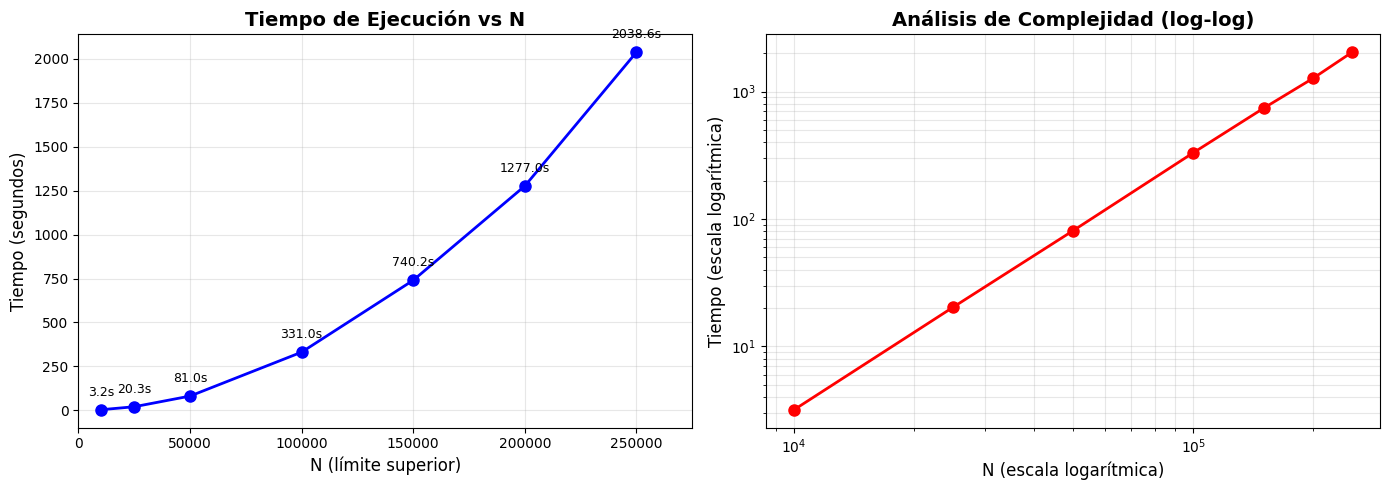


ANÁLISIS DE COMPLEJIDAD
Pendiente en escala log-log: 2.00
Esto sugiere una complejidad aproximada de O(n^2.00)

COMPARACIÓN DE INCREMENTOS
De 10000 a 25000: 
  N aumenta 2.50x
  Tiempo aumenta 6.37x
De 25000 a 50000: 
  N aumenta 2.00x
  Tiempo aumenta 4.00x
De 50000 a 100000: 
  N aumenta 2.00x
  Tiempo aumenta 4.09x
De 100000 a 150000: 
  N aumenta 1.50x
  Tiempo aumenta 2.24x
De 150000 a 200000: 
  N aumenta 1.33x
  Tiempo aumenta 1.73x
De 200000 a 250000: 
  N aumenta 1.25x
  Tiempo aumenta 1.60x

Resultados guardados en 'resultados_mediciones.csv'
Gráficos guardados en 'tiempos_ejecucion.png'


In [4]:

# Crear tabla de resultados
print("\n" + "="*60)
print("TABLA DE RESULTADOS")
print("="*60)
print(f"{'N':>10} | {'Tiempo (s)':>12} | {'Pares':>10}")
print("-"*60)
for i, n in enumerate(intervalos):
    print(f"{n:>10} | {tiempos[i]:>12.2f} | {resultados[i]:>10}")

# Graficar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de tiempos
ax1.plot(intervalos, tiempos, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('N (límite superior)', fontsize=12)
ax1.set_ylabel('Tiempo (segundos)', fontsize=12)
ax1.set_title('Tiempo de Ejecución vs N', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(intervalos) * 1.1)

# Añadir etiquetas a los puntos
for i, (x, y) in enumerate(zip(intervalos, tiempos)):
    ax1.annotate(f'{y:.1f}s', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

# Gráfico de complejidad (log-log para analizar complejidad)
ax2.loglog(intervalos, tiempos, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('N (escala logarítmica)', fontsize=12)
ax2.set_ylabel('Tiempo (escala logarítmica)', fontsize=12)
ax2.set_title('Análisis de Complejidad (log-log)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig('tiempos_ejecucion.png', dpi=300, bbox_inches='tight')
plt.show()

# Análisis de complejidad
print("\n" + "="*60)
print("ANÁLISIS DE COMPLEJIDAD")
print("="*60)

# Calcular la pendiente en escala log-log para estimar la complejidad
log_n = np.log(intervalos[1:])
log_t = np.log(tiempos[1:])
pendiente = np.polyfit(log_n, log_t, 1)[0]

print(f"Pendiente en escala log-log: {pendiente:.2f}")
print(f"Esto sugiere una complejidad aproximada de O(n^{pendiente:.2f})")

# Comparación de tiempos
if len(tiempos) >= 2:
    print("\n" + "="*60)
    print("COMPARACIÓN DE INCREMENTOS")
    print("="*60)
    for i in range(1, len(intervalos)):
        incremento_n = intervalos[i] / intervalos[i-1]
        incremento_t = tiempos[i] / tiempos[i-1] if tiempos[i-1] > 0 else 0
        print(f"De {intervalos[i-1]} a {intervalos[i]}: ")
        print(f"  N aumenta {incremento_n:.2f}x")
        print(f"  Tiempo aumenta {incremento_t:.2f}x")

# Guardar resultados en archivo CSV
import csv

with open('resultados_mediciones.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['N', 'Tiempo (s)', 'Pares encontrados'])
    for i, n in enumerate(intervalos):
        writer.writerow([n, f'{tiempos[i]:.2f}', resultados[i]])

print(f"\nResultados guardados en 'resultados_mediciones.csv'")
print(f"Gráficos guardados en 'tiempos_ejecucion.png'")